In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salader/dogsvscats")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'dogsvscats' dataset.
Path to dataset files: /kaggle/input/dogsvscats


In [3]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, Flatten, Input, MaxPooling2D, Flatten, Dropout, BatchNormalization
import matplotlib.pyplot as plt

In [4]:
train_ds = keras.utils.image_dataset_from_directory(
    directory=f'{path}/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

# Load the validation dataset
validation_ds = keras.utils.image_dataset_from_directory(
    directory=f'{path}/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [5]:
for (image , label) in train_ds:
  print(label)
  print(image.shape)
  break


tf.Tensor([1 1 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0 1 0 0 1 0 1 1 1 0 1 1 1 1 1 0], shape=(32,), dtype=int32)
(32, 256, 256, 3)


In [6]:
def process(image, label):
    image = tf.cast(image / 255., tf.float32)
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [7]:
for (image , label) in train_ds:
  print(label[0])
  print(image[0])
  break

tf.Tensor(1, shape=(), dtype=int32)
tf.Tensor(
[[[0.29641956 0.28268343 0.22484179]
  [0.6635724  0.66245544 0.60109985]
  [0.75846046 0.77269846 0.7120527 ]
  ...
  [0.527658   0.42961875 0.272756  ]
  [0.5311671  0.42634934 0.2717461 ]
  [0.6176241  0.5078202  0.354879  ]]

 [[0.28129673 0.2531366  0.18790673]
  [0.5918558  0.58004516 0.5090605 ]
  [0.8194404  0.8278137  0.75265884]
  ...
  [0.49573484 0.3903197  0.23345695]
  [0.49289796 0.37857506 0.22623129]
  [0.5818091  0.46416208 0.31514245]]

 [[0.2709413  0.22393662 0.1481322 ]
  [0.34129548 0.30835387 0.22870411]
  [0.6483974  0.63145995 0.54724085]
  ...
  [0.5068551  0.39705116 0.24018842]
  [0.49142978 0.37474066 0.22239691]
  [0.5838312  0.458341   0.30932137]]

 ...

 [[0.58617496 0.4591835  0.25918353]
  [0.59897417 0.46569502 0.26086965]
  [0.6014629  0.46120557 0.24801624]
  ...
  [0.60775036 0.46825394 0.26557815]
  [0.6068173  0.4549408  0.25038296]
  [0.6786918  0.5179075  0.3139859 ]]

 [[0.5773559  0.46418187 0.

In [8]:
model = Sequential()

model.add(Input(shape=(256, 256, 3)))
model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), padding='same'))

model.add(Conv2D(64, kernel_size=(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), padding='same'))

model.add(Conv2D(128, kernel_size=(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), padding='same'))

model.add(Flatten())

model.add(Dense(32, activation='relu', kernel_initializer='he_uniform', kernel_regularizer=keras.regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu', kernel_initializer='he_uniform', kernel_regularizer=keras.regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Dense(32, activation='relu', kernel_initializer='he_uniform', kernel_regularizer=keras.regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │     4,194,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,291,009 (16.37 MB)

 Trainable params: 4,290,369 (16.37 MB)

 Non-trainable params: 640 (2.50 KB)

In [9]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [10]:
history = model.fit(train_ds, epochs=20, validation_data=validation_ds)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 96s 125ms/step - accuracy: 0.6319 - loss: 0.9635 - val_accuracy: 0.6712 - val_loss: 0.8882
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.7218 - loss: 0.7976 - val_accuracy: 0.6968 - val_loss: 0.8531
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 102ms/step - accuracy: 0.7721 - loss: 0.7404 - val_accuracy: 0.7016 - val_loss: 0.8101
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 104ms/step - accuracy: 0.8033 - loss: 0.7293 - val_accuracy: 0.7968 - val_loss: 0.7617
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 64s 103ms/step - accuracy: 0.8312 - loss: 0.7179 - val_accuracy: 0.7912 - val_loss: 0.8482
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 64s 103ms/step - accuracy: 0.8511 - loss: 0.7204 - val_accuracy: 0.8220 - val_loss: 0.7982
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 104ms/step - accuracy: 0.8678 - loss: 0.7057 - val_accuracy: 0.7956 - val_loss: 0.8570
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 104ms/step - accuracy: 0.8835 - loss: 0.

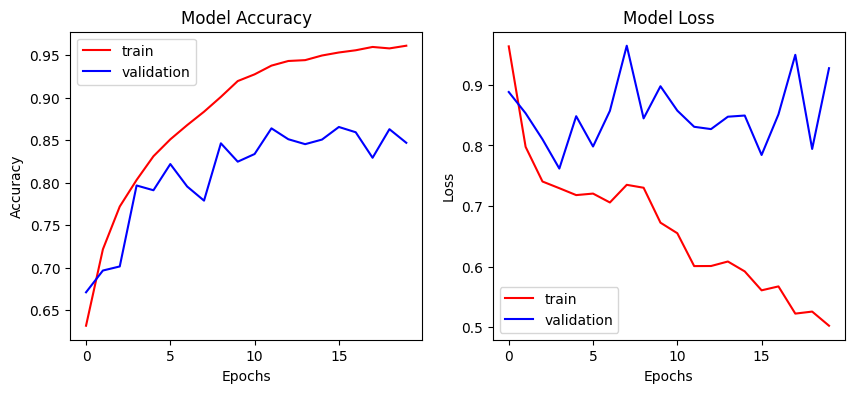

In [13]:
# Plot Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

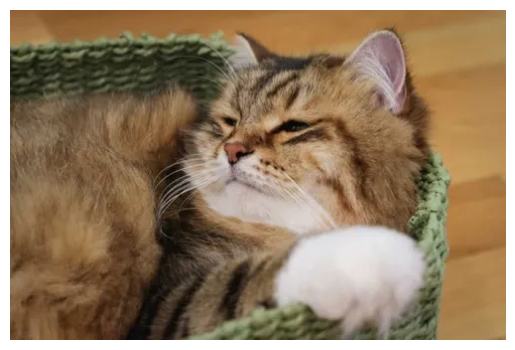

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Raw Prediction Value: 0.0023394154850393534
Prediction: It's a CAT!


In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

image_path = '/content/Brown-White-Siberian-Cat-Laying-In-Green-Basket-7-compressed-540x360.webp'

if os.path.exists(image_path):
    test_img = cv2.imread(image_path)
    # Convert BGR (OpenCV default) to RGB for correct matplotlib plotting
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    plt.imshow(test_img_rgb)
    plt.axis('off')
    plt.show()

    # Preprocess the image to fit model expectations
    test_img_resized = cv2.resize(test_img, (256, 256))
    test_input = test_img_resized.reshape((1, 256, 256, 3))

    # Scale image pixels
    test_input = test_input / 255.0

    # Get class names from the dataset
    class_names = train_ds.class_names  # e.g., ['cat', 'dog']

    # Predict raw output (sigmoid probability for binary classification)
    raw_prediction = model.predict(test_input)
    
    # Sigmoid output >= 0.5 maps to class index 1, otherwise class index 0
    predicted_class_idx = int(raw_prediction[0][0] >= 0.5)
    predicted_class_name = class_names[predicted_class_idx]

    print(f"Predicted Class Index: {predicted_class_idx}")
    print(f"Predicted Class Name: {predicted_class_name}")

else:
    print(f"Image not found at {image_path}. Please check your path.")